In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Telco-Customer-Churn.csv')

print(df.shape)         # how many rows & columns
print(df.head())        # first 5 rows
print(df.dtypes)        # data types
print(df.isnull().sum()) # missing values

(7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Co

Dataset has 7043 rows and 21 columns. TotalCharges has 11 missing values. customerID is not useful for modeling

In [3]:
# TotalCharges is stored as string — convert it
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop customerID — useless for ML
df.drop('customerID', axis=1, inplace=True)

# Fill the 11 missing TotalCharges with median
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

print(df.isnull().sum())  # should show 0 now

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


C:\Users\HP\AppData\Local\Temp\ipykernel_2052\128507192.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Rate: 26.54%


C:\Users\HP\AppData\Local\Temp\ipykernel_2052\4135677046.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='Set2')


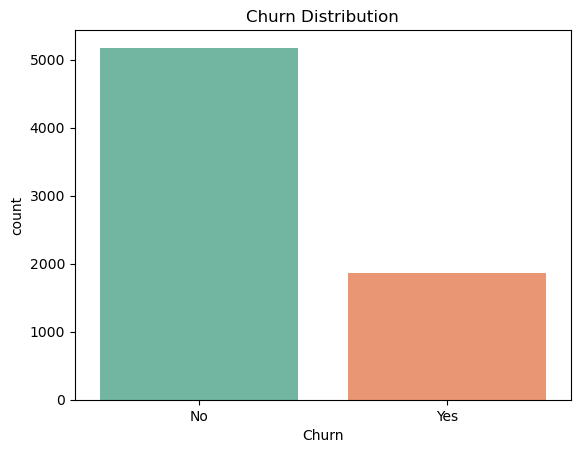

In [4]:
churn_counts = df['Churn'].value_counts()
print(churn_counts)
print(f"\nChurn Rate: {churn_counts['Yes'] / len(df) * 100:.2f}%")

# Plot
sns.countplot(x='Churn', data=df, palette='Set2')
plt.title('Churn Distribution')
plt.show()

Dataset is imbalanced — only 26.54% customers churned. We'll need to handle this before modeling.

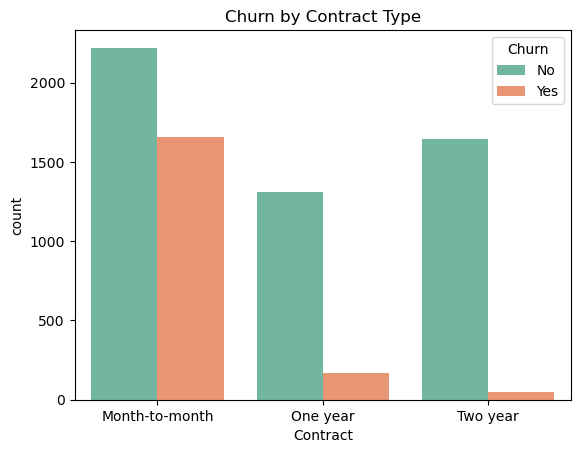

Churn                 No       Yes
Contract                          
Month-to-month  0.572903  0.427097
One year        0.887305  0.112695
Two year        0.971681  0.028319


In [5]:
sns.countplot(x='Contract', hue='Churn', data=df, palette='Set2')
plt.title('Churn by Contract Type')
plt.show()

# Exact numbers
print(df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack())

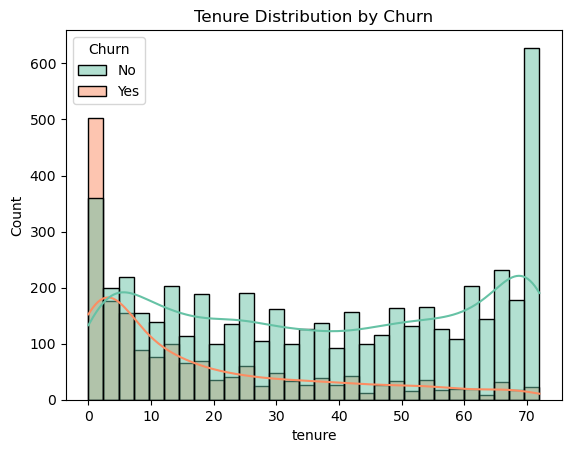

In [6]:
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, kde=True, palette='Set2')
plt.title('Tenure Distribution by Churn')
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_2052\4262600196.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='Set2')


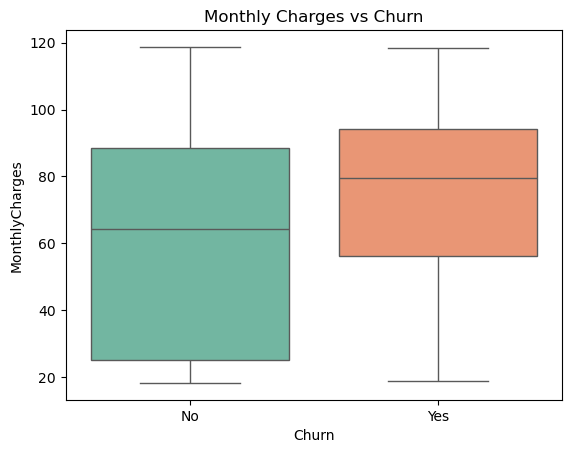

In [7]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='Set2')
plt.title('Monthly Charges vs Churn')
plt.show()

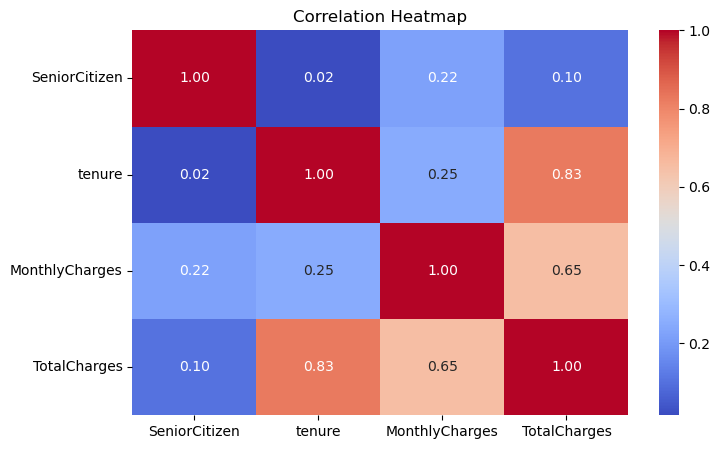

In [8]:
numeric_cols = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,5))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

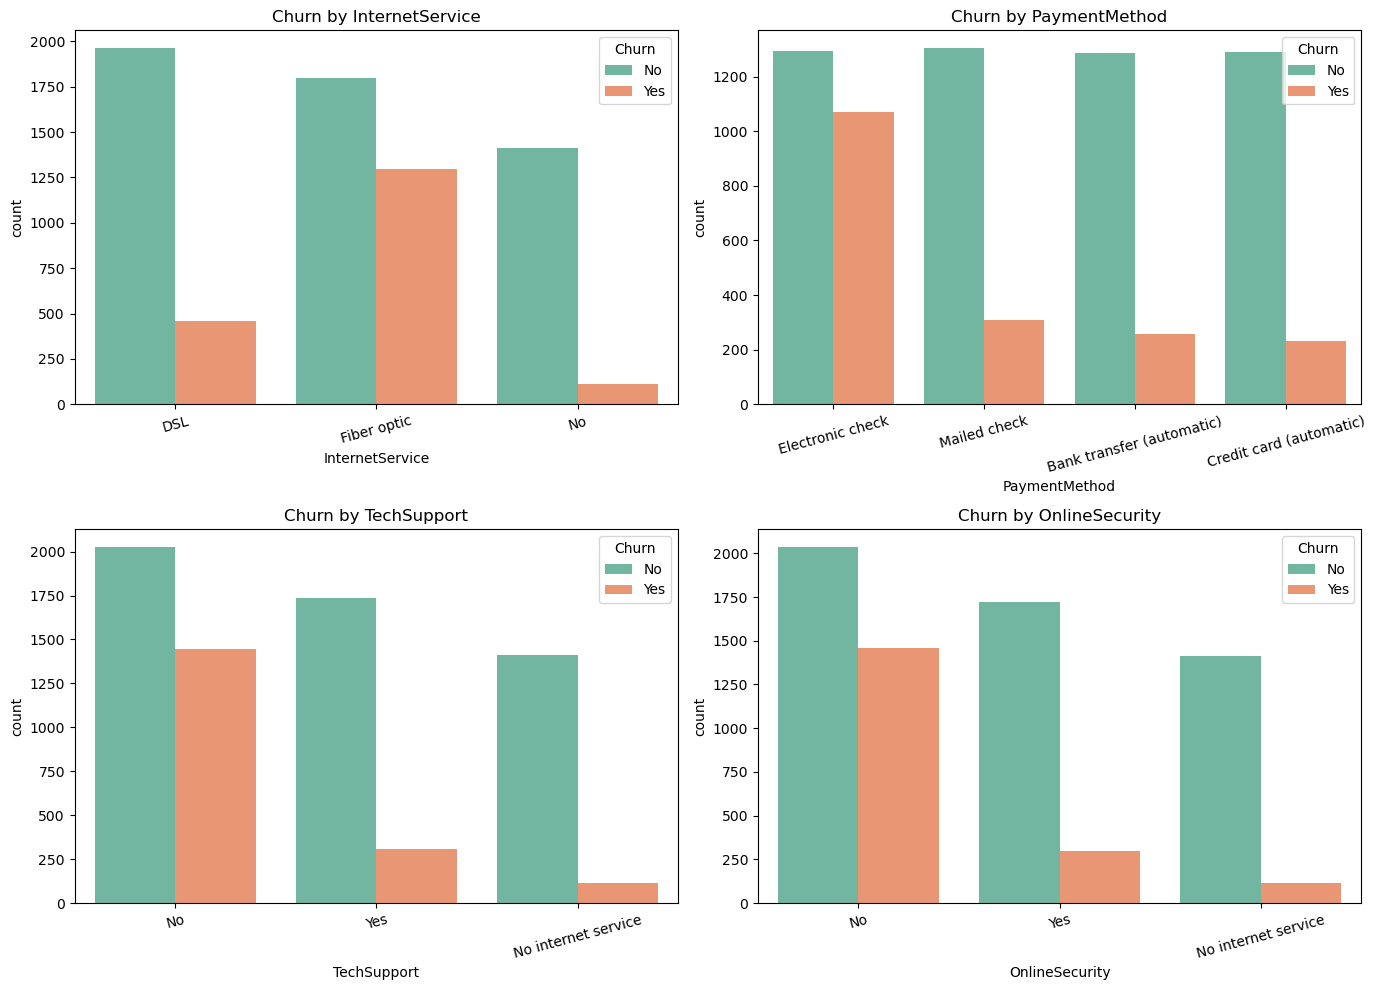

In [9]:
cat_cols = ['InternetService', 'PaymentMethod', 'TechSupport', 'OnlineSecurity']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axes.flatten(), cat_cols):
    sns.countplot(x=col, hue='Churn', data=df, ax=ax, palette='Set2')
    ax.set_title(f'Churn by {col}')
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()